# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV587"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv587')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv587/lv587-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV587,gene_band
0,PDE5A,4.701447,4q26
1,PLAU,3.255255,10q22.2
2,PLAT,3.166500,8p11.21
3,F2R,3.097730,5q13.3
4,LPAR1,2.665312,9q31.3
5,HGF,2.505001,7q21.11
6,COL6A3,2.400443,2q37.3
7,LTBP1,2.223807,2p22.3
8,GAS6,2.178220,13q34
9,ITGA1,2.067799,5q11.2


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:04:02,386 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:04:02,386 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP055569, SRP046254, SRP051599, SRP050179, SRP040243, SRP049061, SRP012607, SRP044763, SRP067529, SRP049507, SRP017142, SRP045867, SRP056989, SRP017631, SRP034541, SRP033401, SRP007461, SRP060598, SRP015976, SRP043510, SRP017972, SRP007494, SRP041508, SRP009862, SRP064820, SRP066917, SRP034163, SRP016790, SRP033131, SRP014320, SRP023270, SRP017378, SRP033502, SRP057205, SRP058387, SRP008554, SRP050499, SRP041387, SRP033351, SRP004637, SRP050374, SRP007481, SRP018218, SRP043162, SRP051606, SRP016059, SRP039397, SRP009266, SRP064464, SRP037550, SRP041036, SRP066834, SRP041063, SRP041573, SRP055153, SRP057196, SRP057251, SRP056146, SRP042161, SRP049340, SRP004042, SRP033135, SRP012167, SRP068942, SRP047299, SRP060416, SRP056330, SRP050534, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (64 != 68)
  warnings.warn(


In [12]:
lv_data.shape

(5235, 93)

In [13]:
lv_data.head()

cell type cell line  \
project   run                                                      
SRP055569 SRR1821717  MCF10a human breast cancer cells       NaN   
          SRR1821716  MCF10a human breast cancer cells       NaN   
          SRR1821715  MCF10a human breast cancer cells       NaN   
          SRR1821714  MCF10a human breast cancer cells       NaN   
          SRR1821713  MCF10a human breast cancer cells       NaN   

                     days after 4oht induction passage population doublings  \
project   run                                                                 
SRP055569 SRR1821717                       NaN     NaN                  NaN   
          SRR1821716                       NaN     NaN                  NaN   
          SRR1821715                       NaN     NaN                  NaN   
          SRR1821714                       NaN     NaN                  NaN   
          SRR1821713                       NaN     NaN                  NaN   

                     treatment age category tissue duration transfection  ...  \
project   run                                                             ...   
SRP055569 SRR1821717       NaN          NaN    NaN      NaN          NaN  ...   
          SRR1821716       NaN          NaN    NaN      NaN          NaN  ...   
          SRR1821715       NaN          NaN    NaN      NaN          NaN  ...   
          SRR1821714       NaN          NaN    NaN      NaN          NaN  ...   
          SRR1821713       NaN          NaN    NaN      NaN          NaN  ...   

                     patient agent agasga braf/nras mutation tonsil donor  \
project   run                                                               
SRP055569 SRR1821717     NaN   NaN    NaN                NaN          NaN   
          SRR1821716     NaN   NaN    NaN                NaN          NaN   
          SRR1821715     NaN   NaN    NaN                NaN          NaN   
          SRR1821714     NaN   NaN    NaN                NaN          NaN   
          SRR1821713     NaN   NaN    NaN                NaN          NaN   

                     facs gating patient number patient age sources     LV587  
project   run                                                                  
SRP055569 SRR1821717         NaN            NaN         NaN     NaN -0.051419  
          SRR1821716         NaN            NaN         NaN     NaN -0.012436  
          SRR1821715         NaN            NaN         NaN     NaN -0.017785  
          SRR1821714         NaN            NaN         NaN     NaN -0.022693  
          SRR1821713         NaN            NaN         NaN     NaN  0.061804  

[5 rows x 93 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

passage                      0.142393
population doublings         0.104830
transfection                 0.093858
restriction enzyme           0.084947
experiment                   0.084947
age category                 0.079355
treatment                    0.068156
cell line                    0.054855
genotype/variation           0.047792
infected with                0.039890
passages                     0.039723
infection                    0.038279
cell state                   0.036939
days after 4oht induction    0.036012
antibody                     0.030218
cell line(s)                 0.028402
data type                    0.027511
cell modifications           0.022351
sample type                  0.021395
cell type                    0.020483
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line       0.054855
cell type       0.020483
tissue          0.010533
cell subtype    0.004395
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [17]:
lv_attrs_selected = [
    "cell line",
    "cell type",
    "tissue",
    "cell subtype",
]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

cell line  \
project   run                    
SRP055569 SRR2019068       NaN   
SRP046254 SRR1567496     IRM90   
SRP051599 SRR1736331     MRC-5   
SRP050179 SRR1660559       NaN   
SRP051599 SRR1736332     MRC-5   
SRP046254 SRR1567492     IRM90   
SRP051599 SRR1736328     MRC-5   
SRP050179 SRR1660534       NaN   
          SRR1660560       NaN   
          SRR1660536       NaN   
SRP040243 SRR1197245     IMR90   
SRP050179 SRR1660535       NaN   
SRP051599 SRR1736330     MRC-5   
SRP046254 SRR1567488     IRM90   
SRP050179 SRR1660558       NaN   
SRP051599 SRR1736327     MRC-5   
          SRR1736329     MRC-5   
SRP046254 SRR1567495     IRM90   
          SRR1567487     IRM90   
          SRR1567491     IRM90   
SRP055569 SRR2019145       NaN   
SRP046254 SRR1567493     IRM90   
          SRR1567489     IRM90   
SRP049061 SRR1616854  CCD-18Co   
          SRR1616855  CCD-18Co   

                                                              cell type  \
project   run                                                             
SRP055569 SRR2019068                  WI-38 human lung fibroblast cells   
SRP046254 SRR1567496                                    senescent cells   
SRP051599 SRR1736331                                        fibroblasts   
SRP050179 SRR1660559                                  Wi-38 fibroblasts   
SRP051599 SRR1736332                                        fibroblasts   
SRP046254 SRR1567492                                    senescent cells   
SRP051599 SRR1736328                                        fibroblasts   
SRP050179 SRR1660534                                  MRC-5 fibroblasts   
          SRR1660560                                  Wi-38 fibroblasts   
          SRR1660536                                  MRC-5 fibroblasts   
SRP040243 SRR1197245                                                NaN   
SRP050179 SRR1660535                                  MRC-5 fibroblasts   
SRP051599 SRR1736330                                        fibroblasts   
SRP046254 SRR1567488                                    senescent cells   
SRP050179 SRR1660558                                  Wi-38 fibroblasts   
SRP051599 SRR1736327                                        fibroblasts   
          SRR1736329                                        fibroblasts   
SRP046254 SRR1567495                                Non-senescent cells   
          SRR1567487                                Non-senescent cells   
          SRR1567491                                Non-senescent cells   
SRP055569 SRR2019145  mixture of U87 human glioma cells and WI-38 hu...   
SRP046254 SRR1567493               senescent cells expressing ZFP36L1wt   
          SRR1567489               senescent cells expressing ZFP36L1wt   
SRP049061 SRR1616854     normal intestinal subepithelial myofibroblasts   
          SRR1616855     normal intestinal subepithelial myofibroblasts   

                     tissue cell subtype     LV587  
project   run                                       
SRP055569 SRR2019068    NaN          NaN  1.106910  
SRP046254 SRR1567496    NaN          NaN  1.031431  
SRP051599 SRR1736331    NaN          NaN  1.020351  
SRP050179 SRR1660559    NaN          NaN  1.016142  
SRP051599 SRR1736332    NaN          NaN  1.005172  
SRP046254 SRR1567492    NaN          NaN  1.003622  
SRP051599 SRR1736328    NaN          NaN  1.001226  
SRP050179 SRR1660534    NaN          NaN  1.001202  
          SRR1660560    NaN          NaN  1.000525  
          SRR1660536    NaN          NaN  0.998988  
SRP040243 SRR1197245   Lung          NaN  0.996728  
SRP050179 SRR1660535    NaN          NaN  0.995737  
SRP051599 SRR1736330    NaN          NaN  0.994218  
SRP046254 SRR1567488    NaN          NaN  0.985494  
SRP050179 SRR1660558    NaN          NaN  0.977836  
SRP051599 SRR1736327    NaN          NaN  0.965120  
          SRR1736329    NaN          NaN  0.963916  
SRP046254 SRR1567495    NaN          NaN  0.948901  
          SRR156

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

cell line  \
project   run                                                       
SRP049061 SRR1616853                                     CCD-18Co   
          SRR1616856                                     CCD-18Co   
          SRR1616857                                     CCD-18Co   
          SRR1616858                                     CCD-18Co   
SRP046254 SRR1567497                                        IRM90   
SRP012607 SRR493377                                           NaN   
          SRR493371                                           NaN   
          SRR493375                                           NaN   
SRP051599 SRR1736322                                        MRC-5   
SRP050179 SRR2751125                                          NaN   
SRP012607 SRR493369                                           NaN   
SRP044763 SRR1523603  IMR90 human primary lung embryo fibroblasts   
SRP051599 SRR1736321                                        MRC-5   
SRP012607 SRR493376                                           NaN   
          SRR493370                                           NaN   
SRP049061 SRR1616860                                     CCD-18Co   
          SRR1616861                                     CCD-18Co   
          SRR1616859                                     CCD-18Co   
SRP050179 SRR2751127                                          NaN   
SRP044763 SRR1523608  IMR90 human primary lung embryo fibroblasts   
SRP051599 SRR1736323                                        MRC-5   
SRP067529 SRR3030743           Parkin-expressing MRC5 fibroblasts   
SRP049061 SRR1616845                                     CCD-18Co   
SRP049507 SRR1639741                                         WI38   
SRP049061 SRR1616846                                     CCD-18Co   

                                                           cell type  \
project   run                                                          
SRP049061 SRR1616853  normal intestinal subepithelial myofibroblasts   
          SRR1616856  normal intestinal subepithelial myofibroblasts   
          SRR1616857  normal intestinal subepithelial myofibroblasts   
          SRR1616858  normal intestinal subepithelial myofibroblasts   
SRP046254 SRR1567497            senescent cells expressing ZFP36L1wt   
SRP012607 SRR493377                                              NaN   
          SRR493371                                              NaN   
          SRR493375                                              NaN   
SRP051599 SRR1736322                                     fibroblasts   
SRP050179 SRR2751125                                           MRC-5   
SRP012607 SRR493369                                              NaN   
SRP044763 SRR1523603                         contact-inhibited IMR90   
SRP051599 SRR1736321                                     fibroblasts   
SRP012607 SRR493376                                              NaN   
          SRR493370                                              NaN   
SRP049061 SRR1616860  normal intestinal subepithelial myofibroblasts   
          SRR1616861  normal intestinal subepithelial myofibroblasts   
          SRR1616859  normal intestinal subepithelial myofibroblasts   
SRP050179 SRR2751127                                           MRC-5   
SRP044763 SRR1523608                         contact-inhibited IMR90   
SRP051599 SRR1736323                                     fibroblasts   
SRP067529 SRR3030743                                             NaN   
SRP049061 SRR1616845  normal intestinal subepithelial myofibroblasts   
SRP049507 SRR1639741                                    Normal Cells   
SRP049061 SRR1616846  normal intestinal subepithelial myofibroblasts   

                                tissue cell subtype     LV587  
project   run                                                  
SRP049061 SRR1616853               NaN          NaN  0.816593  
          SRR1616856               NaN          NaN  0.

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# # list the top 10 samples from this project
# lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
#     LV_NAME, ascending=False
# ).head(10)

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "cell type",
    "tissue",
    "cell subtype",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

cell line     LV587
project   run                                                    
SRP055569 SRR2019068  WI-38 human lung fibroblast cells  1.106910
SRP046254 SRR1567496                              IRM90  1.031431
SRP051599 SRR1736331                              MRC-5  1.020351
SRP050179 SRR1660559                  Wi-38 fibroblasts  1.016142
SRP051599 SRR1736332                              MRC-5  1.005172
SRP046254 SRR1567492                              IRM90  1.003622
SRP051599 SRR1736328                              MRC-5  1.001226
SRP050179 SRR1660534                  MRC-5 fibroblasts  1.001202
          SRR1660560                  Wi-38 fibroblasts  1.000525
          SRR1660536                  MRC-5 fibroblasts  0.998988
SRP040243 SRR1197245                              IMR90  0.996728
SRP050179 SRR1660535                  MRC-5 fibroblasts  0.995737
SRP051599 SRR1736330                              MRC-5  0.994218
SRP046254 SRR1567488                              IRM90  0.985494
SRP050179 SRR1660558                  Wi-38 fibroblasts  0.977836
SRP051599 SRR1736327                              MRC-5  0.965120
          SRR1736329                              MRC-5  0.963916
SRP046254 SRR1567495                              IRM90  0.948901
          SRR1567487                              IRM90  0.945794
          SRR1567491                              IRM90  0.936745

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['WI-38 human lung fibroblast cells',
 'IRM90',
 'MRC-5',
 'Wi-38 fibroblasts',
 'MRC-5 fibroblasts']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

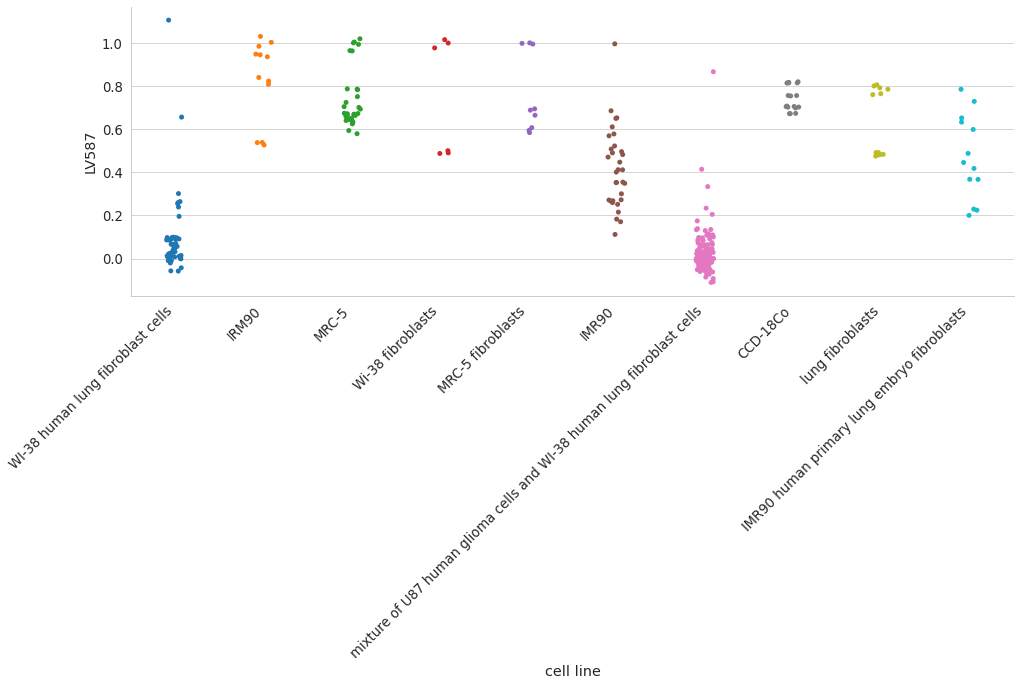

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Detroit")
    ]
    display(_tmp.head(20))

cell line     LV874
project   run                              
SRP057205 SRR1975480  Detroit 551  7.145822
          SRR1975479  Detroit 551  7.145625
          SRR1975494  Detroit 551  0.920045
          SRR1975493  Detroit 551  0.919606
          SRR1975455  Detroit 551  0.528382
          SRR1975456  Detroit 551  0.527711
          SRR1975473  Detroit 551  0.480429
          SRR1975474  Detroit 551  0.479731
          SRR1975457  Detroit 551  0.417292
          SRR1975458  Detroit 551  0.416320
          SRR1975477  Detroit 551  0.409184
          SRR1975478  Detroit 551  0.408183
          SRR1975504  Detroit 551  0.365405
          SRR1975503  Detroit 551  0.361580
          SRR1975459  Detroit 551  0.237731
          SRR1975460  Detroit 551  0.236578
          SRR1975490  Detroit 551  0.233294
          SRR1975489  Detroit 551  0.231456
          SRR1975475  Detroit 551  0.193915
          SRR1975476  Detroit 551  0.191678

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057205, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057205"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line gfp cd13 ssea4 tra160     LV874
project   run                                                    
SRP057205 SRR1975480  Detroit 551   +    +     +     NA  7.145822
          SRR1975479  Detroit 551   +    +     +     NA  7.145625
          SRR1975494  Detroit 551   -   NA     +      +  0.920045
          SRR1975493  Detroit 551   -   NA     +      +  0.919606
          SRR1975455  Detroit 551  NA   NA    NA     NA  0.528382
          SRR1975456  Detroit 551  NA   NA    NA     NA  0.527711
          SRR1975463           H1  NA   NA    NA     NA  0.522837
          SRR1975464           H1  NA   NA    NA     NA  0.521473
          SRR1975473  Detroit 551   +    +    NA     NA  0.480429
          SRR1975474  Detroit 551   +    +    NA     NA  0.479731
          SRR1975457  Detroit 551  NA   NA    NA     NA  0.417292
          SRR1975458  Detroit 551  NA   NA    NA     NA  0.416320
          SRR1975477  Detroit 551   +    +     -     NA  0.409184
          SRR1975478  Detroit 551   +    +     -     NA  0.408183
          SRR1975504  Detroit 551   -   NA     +      +  0.365405
          SRR1975503  Detroit 551   -   NA     +      +  0.361580
          SRR1975465           H9  NA   NA    NA     NA  0.319867
          SRR1975466           H9  NA   NA    NA     NA  0.319864
          SRR1975459  Detroit 551  NA   NA    NA     NA  0.237731
          SRR1975460  Detroit 551  NA   NA    NA     NA  0.236578
          SRR1975490  Detroit 551   +   NA     +      -  0.233294
          SRR1975489  Detroit 551   +   NA     +      -  0.231456
          SRR1975475  Detroit 551   +    -     -     NA  0.193915
          SRR1975476  Detroit 551   +    -     -     NA  0.191678
          SRR1975471  Detroit 551   +    +    NA     NA  0.190481
          SRR1975472  Detroit 551   +    +    NA     NA  0.190401
          SRR1975487  Detroit 551   -   NA     +      -  0.185547
          SRR1975468         PGP1  NA   NA    NA     NA  0.183946
          SRR1975467         PGP1  NA   NA    NA     NA  0.182994
          SRR1975488  Detroit 551   -   NA     +      -  0.178383
          SRR1975481  Detroit 551   +    -     +     NA  0.142276
          SRR1975482  Detroit 551   +    -     +     NA  0.141954
          SRR1975469  Detroit 551   +    -    NA     NA  0.089477
          SRR1975470  Detroit 551   +    -    NA     NA  0.088974
          SRR1975499  Detroit 551   -   NA     +      -  0.073286
          SRR1975500  Detroit 551   -   NA     +      -  0.072839
          SRR1975495  Detroit 551   +   NA     -      -  0.071876
          SRR1975496  Detroit 551   +   NA     -      -  0.071729
          SRR1975491  Detroit 551   -   NA     +      +  0.061450
          SRR1975492  Detroit 551   -   NA     +      +  0.061157
          SRR1975485  Detroit 551   +   NA     -      -  0.051326
          SRR1975486  Detroit 551   +   NA     -      -  0.049432
          SRR1975453  Detroit 551  NA   NA    NA     NA  0.049123
          SRR1975454  Detroit 551  NA   NA    NA     NA  0.049008
          SRR1975501  Detroit 551   -   NA     +      +  0.044060
          SRR1975502  Detroit 551   -   NA     +      +  0.043984
          SRR1975498  Detroit 551   +   NA     +      -  0.038335
          SRR1975497  Detroit 551   +   NA     +      -  0.038302
          SRR1975484  Detroit 551   -    -     +     NA  0.018635
          SRR1975483  Detroit 551   -    -     +     NA  0.018549
          SRR1975505  Detroit 551  NA   NA    NA     NA  0.010443
          SRR1975506  Detroit 551  NA   NA    NA     NA  0.007838
          SRR1975507  Detroit 551  NA   NA    NA     NA  0.004690
          SRR1975508  Detroit 551  NA   NA    NA     NA  0.000223
          SRR1975462  Detroit 551  NA   NA    NA     NA -0.018291
          SRR1975461  Detroit 551  NA   NA    NA     NA -0.018472

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.